# 历年国赛 / 美赛中的微分方程与差分方程｜小白详解实战课件

> 4 道真实往年赛题的教学化求解：题目是什么 → 怎么分析 → 为什么这样建模 → 代码怎么跑 → 图表怎么看 → 结论怎么写。

## 先说明这份课件的边界

这不是历年获奖论文的复制，也不是声称给出赛题唯一答案。数学建模竞赛本来就没有唯一标准模型。本课件做的是：

1. 选取真实往年赛题；
2. 保留题目的核心机制；
3. 为了让初学者能独立运行，使用明确写出的**教学参数或简化数据**；
4. 给出一套逻辑完整、能运行、能解释、能继续扩展的基线方案。

如果正式参赛，必须进一步查找数据、估计参数、验证模型、讨论不确定性，并按题目要求完成论文。

## 本课选取的 4 道题

|年份与赛事|题目|主要方法|本课回答的核心问题|
|---|---|---|---|
|2003 全国大学生数学建模竞赛 A 题|SARS 的传播|SEIR 常微分方程|隔离早 5 天或晚 5 天，峰值会怎样？|
|2007 全国大学生数学建模竞赛 A 题|中国人口增长预测|Leslie 型年龄结构差分方程|低、中、高生育情景下，总人口和老龄化怎样变化？|
|2016 MCM Problem A|A Hot Bath（热水浴）|热量守恒微分方程、双区域模型|怎样兼顾水温均匀、接近目标温度和节水？|
|2021 MCM Problem A|Fungi（真菌）|竞争—分解耦合微分方程|环境波动下，生长快与耐受强的真菌怎样影响分解？|

## 学完应该会什么？

- 能从题目文字里识别“状态、流入、流出、反馈、时间尺度”；
- 能判断使用微分方程还是差分方程；
- 能解释方程每一项，而不是只会复制公式；
- 能用 `solve_ivp` 和矩阵递推完成情景仿真；
- 能从曲线提取峰值、峰值时间、终值、累计量、空间差等指标；
- 能写出模型假设、合理性检查、局限和改进方向。

## 资料来源与题目真实性

- [2003 年国赛赛题官方页面（含 A2003 附件）](https://www.mcm.edu.cn/html_cn/node/0e34562479b6d6d47af380e96fb188f9.html)
- [2007 年国赛赛题官方页面（含 A2007 与数据附件）](https://www.mcm.edu.cn/html_cn/node/a6b7310adbb9eac56152a6815a759986.html)
- [2016 MCM Problem A 官方题面：A Hot Bath](https://www.contest.comap.com/undergraduate/contests/mcm/contests/2016/problems/2016_MCM_Problem_A.pdf)
- [2021 MCM/ICM 官方题目目录](https://www.contest.comap.com/undergraduate/contests/mcm/contests/2021/problems/)
- [COMAP 的 Fungi 题目说明页](https://www.comap.org/membership/member-resources/item/fungi)

本 Notebook 对官方题意做中文概括，不大段复制题面。模型中的演示参数均在对应章节标注，**不能当作官方数据或现实预测**。

# 0. 建模前先掌握一套通用拆题法

拿到动态系统赛题，不要急着搜“高级模型”。先问 7 个问题：

1. **研究对象是谁？** 人、人口、热水、真菌还是木材？
2. **状态变量是什么？** 哪些量会随时间改变，并且必须被保存？
3. **变化来自哪里？** 流入、流出、出生、死亡、感染、换热、竞争？
4. **时间是连续还是离散？** 每秒变化适合微分方程；每年更新适合差分方程。
5. **参数的单位是什么？** `1/天`、`升/分钟`、`人/年`不能乱加。
6. **初始条件是什么？** 没有起点，动态方程通常不能产生唯一轨迹。
7. **输出如何回答题目？** 赛题问“策略”，就不能只画状态曲线，还要设计指标比较策略。

### 万能建模骨架

连续时间常写成：

$$
\frac{d\,状态}{dt}=流入-流出+内部转化。
$$

离散时间常写成：

$$
下一期状态=转移矩阵\times本期状态。
$$

### 为什么还要做检查？

计算机没有常识。即使代码没有报错，也可能算出负人口、感染人数超过总人口、浴缸温度高于进水温度。至少检查：

- 非负性；
- 总量或守恒关系；
- 单位一致；
- 极端参数下是否符合常识；
- 步长或求解精度变化后结论是否稳定。

## 0.1 环境准备

运行下面单元。后面的表格和图片均由代码真实计算，不是手工贴图。

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.integrate import solve_ivp

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 2026
rng = np.random.default_rng(SEED)
COLORS = {
    'navy': '#16324F', 'blue': '#2878B5', 'cyan': '#2A9D8F',
    'yellow': '#E9C46A', 'orange': '#F4A261', 'red': '#E76F51',
    'purple': '#7B6DCC', 'gray': '#7A8793', 'green': '#43AA8B'
}

_installed = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Noto Sans SC', 'Arial Unicode MS']:
    if _name in _installed:
        plt.rcParams['font.sans-serif'] = [_name] + list(plt.rcParams.get('font.sans-serif', []))
        break
plt.rcParams.update({
    'figure.figsize': (10, 5.4), 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20,
    'axes.unicode_minus': False
})

def show_result(table, fig):
    if globals().get('BUILDING_NOTEBOOK', False):
        return
    display(table)
    plt.show()

print('环境就绪：NumPy', np.__version__, '| Pandas', pd.__version__)

环境初始化完成。


# 案例一｜2003 国赛 A 题：SARS 的传播

## 1.1 赛题是什么？

题目要求围绕 SARS 建立传播模型，评价早期模型，建立更可靠的预测与控制模型，并估计严格隔离措施提前或延后若干天造成的影响。它真正考察的不是“背一个 SIR 公式”，而是：

> 如何把感染、潜伏、发病、隔离/康复这些真实过程翻译成动态系统，并用模型比较政策时点。

## 1.2 为什么用微分方程？

在一个足够大的群体中，感染、潜伏和康复几乎每时每刻都在发生。虽然现实人数是整数，但宏观比例可以近似成连续变化，所以适合常微分方程。

最简单的 SIR 只有易感 `S`、感染 `I`、移出 `R`。SARS 有潜伏期，因此本课使用 SEIR：

- $S$：易感者，还没有感染；
- $E$：已经感染但处于潜伏期；
- $I$：具有传染性的感染者；
- $R$：已经康复、被有效隔离或不再参与传播的人。

四个状态像四个房间。人只能按

$$S\rightarrow E\rightarrow I\rightarrow R$$

移动。

## 1.3 从“房间流动”推导 SEIR 方程

$$
\begin{aligned}
\frac{dS}{dt}&=-\beta(t)\frac{SI}{N},\\
\frac{dE}{dt}&=\beta(t)\frac{SI}{N}-\sigma E,\\
\frac{dI}{dt}&=\sigma E-\gamma I,\\
\frac{dR}{dt}&=\gamma I.
\end{aligned}
$$

逐项翻译：

- $\beta SI/N$：易感者与感染者接触后产生的新感染流量；接触越频繁，$\beta$ 越大。
- $\sigma E$：潜伏者转成有传染性者的速度。若平均潜伏期 5 天，可取 $\sigma=1/5$ 每天。
- $\gamma I$：感染者离开传播链的速度。若平均 8 天后被隔离或康复，可取 $\gamma=1/8$ 每天。
- 四条方程相加为 0，所以 $S+E+I+R=N$ 保持不变。这是本模型最重要的守恒检查。

### 隔离措施怎样进入模型？

严格隔离减少有效接触，因此让 $\beta(t)$ 在措施日以后下降：

$$
\beta(t)=\begin{cases}
0.42,&t<t_c,\\
0.09,&t\ge t_c.
\end{cases}
$$

这里 $t_c$ 是严格措施开始日。基线设第 20 天，再比较第 15 天和第 25 天。

> 参数是教学演示值，不是对真实 SARS 的重新估计。真正参赛要用题目附件或可靠数据拟合。

## 1.4 先想清楚“输出”再写代码

只画四条曲线不够回答政策问题。我们至少提取：

- **感染峰值**：医疗系统最吃紧时有多少传播者；
- **峰值时间**：留给系统准备的时间；
- **最终累计感染比例**：长期影响规模；
- **守恒误差**：模型和程序是否明显出错。

预期方向是：越早降低 $\beta$，感染链越早被截断，峰值和累计感染一般越小。但“早 5 天”到底少多少，必须由仿真量化。

指标,数值
干预前近似R0=β/γ,3.360000e+00
干预后近似R=β/γ,7.200000e-01
感染峰值(人),1.049555e+03
峰值日,2.550000e+01
第160天累计移出R(人),7.174710e+03
最大守恒误差(人),1.629815e-09


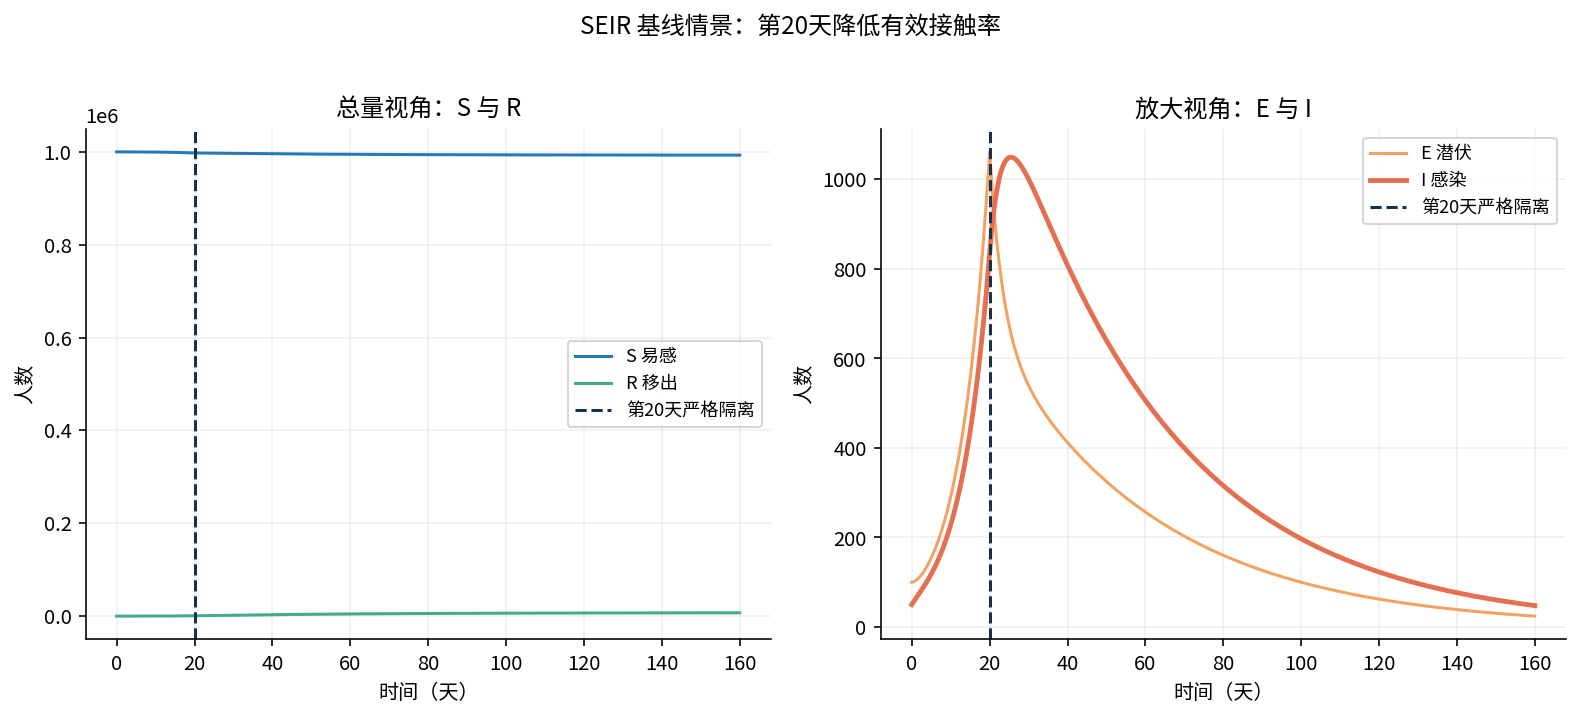

In [2]:
# 案例1A：基线（第20天严格隔离）的 SEIR 轨迹
N = 1_000_000
y0 = np.array([N - 150, 100, 50, 0.0])  # S, E, I, R
sigma, gamma = 1/5, 1/8
beta_before, beta_after = 0.42, 0.09
t_eval = np.linspace(0, 160, 641)

def solve_seir(control_day):
    def rhs(t, y):
        S, E, I, R = y
        beta = beta_before if t < control_day else beta_after
        new_exposed = beta * S * I / N
        return [-new_exposed, new_exposed - sigma*E, sigma*E - gamma*I, gamma*I]
    return solve_ivp(rhs, (0, 160), y0, t_eval=t_eval, rtol=1e-8, atol=1e-9, max_step=0.25)

sol20 = solve_seir(20)
S, E, I, R = sol20.y
peak_idx = np.argmax(I)
mass_error = np.max(np.abs(S + E + I + R - N))

result_table = pd.DataFrame({
    '指标': ['干预前近似R0=β/γ', '干预后近似R=β/γ', '感染峰值(人)', '峰值日', '第160天累计移出R(人)', '最大守恒误差(人)'],
    '数值': [beta_before/gamma, beta_after/gamma, I[peak_idx], sol20.t[peak_idx], R[-1], mass_error]
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(sol20.t, S, label='S 易感', color=COLORS['blue'])
axes[0].plot(sol20.t, R, label='R 移出', color=COLORS['green'])
axes[1].plot(sol20.t, E, label='E 潜伏', color=COLORS['orange'])
axes[1].plot(sol20.t, I, label='I 感染', color=COLORS['red'], linewidth=2.4)
for ax in axes:
    ax.axvline(20, color=COLORS['navy'], linestyle='--', label='第20天严格隔离')
    ax.set_xlabel('时间（天）')
    ax.legend(fontsize=9)
axes[0].set(ylabel='人数', title='总量视角：S 与 R')
axes[1].set(ylabel='人数', title='放大视角：E 与 I')
fig.suptitle('SEIR 基线情景：第20天降低有效接触率', y=1.02)
fig.tight_layout()
show_result(result_table.round(3), fig)

### 1.5 怎样读上一张图？

1. `S` 开始接近总人口，随后下降，表示一部分人被感染后离开易感组。
2. `E` 通常先于 `I` 变化，因为人先进入潜伏状态，再进入具有传染性的状态。
3. 第 20 天后接触率骤降，但 `I` 不会立刻归零。原因是此前已经进入 `E` 的人还会陆续转成 `I`，这叫动态系统的**滞后**。
4. 干预前 $\beta/\gamma>1$，每个感染者平均可以制造超过 1 个后续感染；干预后该比值低于 1，传播链才会总体收缩。
5. 守恒误差应接近数值计算误差。如果误差很大，应先检查方程符号和代码，而不是解释曲线。

下面正式比较提前 5 天、基线和延后 5 天。

情景,严格隔离日,感染峰值(人),峰值日,最终累计移出(人),累计比例(%)
提前5天,15,549.513977,20.5,3757.206252,0.375721
基线,20,1049.555044,25.5,7174.709809,0.717471
延后5天,25,2001.582020,30.5,13574.442753,1.357444


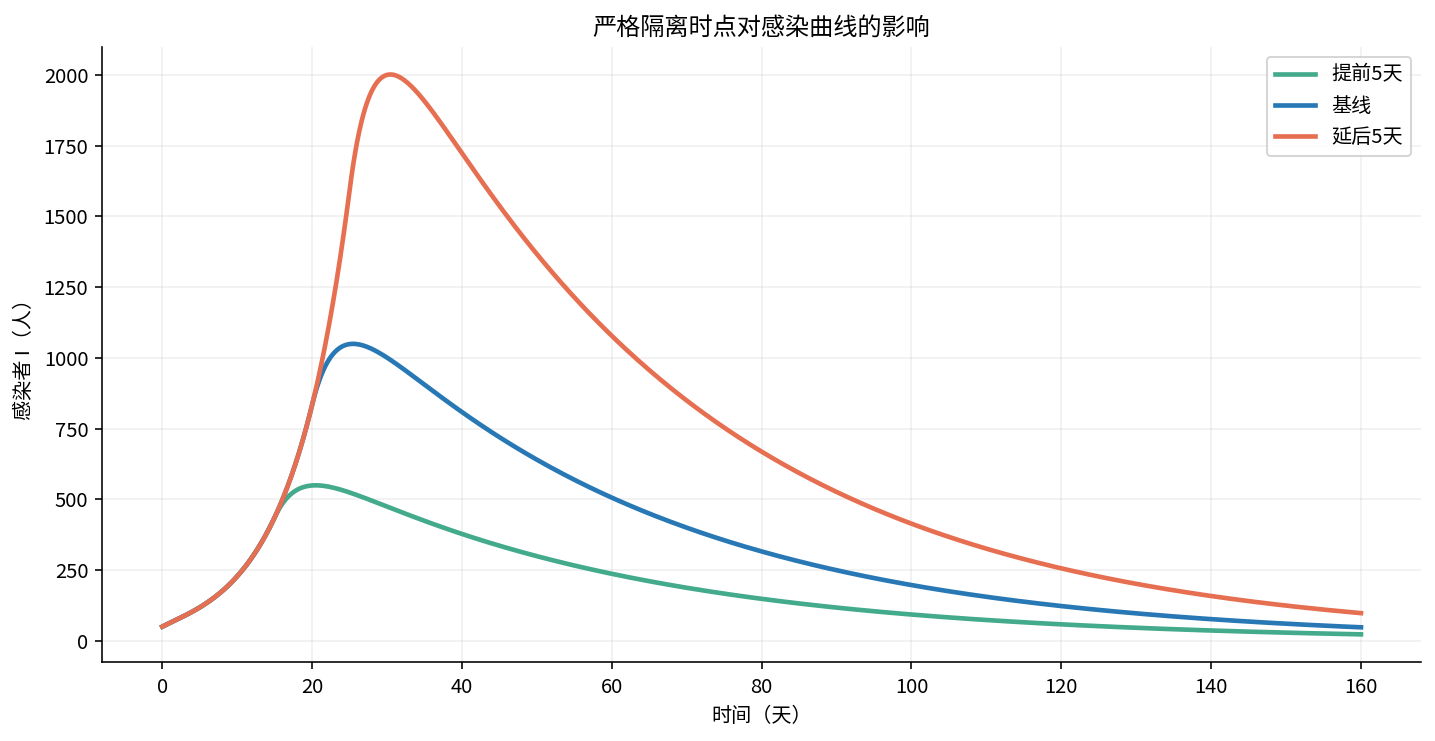

In [3]:
# 案例1B：隔离时点情景比较
rows = []
solutions = {}
for day, label in [(15, '提前5天'), (20, '基线'), (25, '延后5天')]:
    sol = solve_seir(day)
    solutions[label] = sol
    I = sol.y[2]
    R = sol.y[3]
    k = int(np.argmax(I))
    rows.append({
        '情景': label, '严格隔离日': day,
        '感染峰值(人)': I[k], '峰值日': sol.t[k],
        '最终累计移出(人)': R[-1], '累计比例(%)': 100*R[-1]/N
    })
result_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5.2))
for label, color in [('提前5天', COLORS['green']), ('基线', COLORS['blue']), ('延后5天', COLORS['red'])]:
    sol = solutions[label]
    ax.plot(sol.t, sol.y[2], label=label, color=color, linewidth=2.3)
ax.set(xlabel='时间（天）', ylabel='感染者 I（人）', title='严格隔离时点对感染曲线的影响')
ax.legend()
fig.tight_layout()
show_result(result_table.round(2), fig)

## 1.6 可直接用于论文的结果分析思路

表格比“肉眼看曲线”更重要。比较三种情景时，应写成完整因果链：

> 隔离提前 → 高接触率持续时间缩短 → 在潜伏池中积累的人数减少 → 后续转为感染者的人数减少 → 感染峰值和累计感染下降。

还应注意：

- 峰值降低和峰值推迟不是一回事。某些“压平曲线”策略可能把峰值后移，为医疗系统争取时间；强力早干预则可能既降低又提前结束小规模峰值。
- 参数变化会影响数值大小。结论是否稳定，应继续改变 $\beta,\sigma,\gamma$ 做敏感性分析。
- `R` 在这里是“移出传播链”，不一定只表示康复；如果隔离者仍有院内传播，需要增加隔离仓室。
- 真实数据存在漏报、报告延迟和政策执行强度变化，$\beta(t)$ 很少真的瞬间跳变。可以用平滑函数或分阶段参数。

## 1.7 正式参赛还应补什么？

1. 用每日新增、现存、出院等数据估计参数，并给置信区间；
2. 区分确诊前、确诊后、医院内、社区传播；
3. 用训练期拟合、留出期验证预测；
4. 比较 SEIR、时变参数模型和随机模型；
5. 把卫生措施转化成可解释的政策指标，而不是只说“越早越好”。

# 案例二｜2007 国赛 A 题：中国人口增长预测

## 2.1 赛题是什么？

题目要求结合中国人口特点和数据，建立人口增长预测模型。人口预测不能只写

$$P_{t+1}=(1+r)P_t,$$

因为同样是 10 亿人口，“年轻人多”和“老年人多”的未来完全不同。真正决定下一代人口的是年龄结构、生育、死亡和年龄迁移。

## 2.2 为什么用差分方程？

统计数据通常按年发布，年龄每过一年更新一次，因此使用年度离散模型很自然：

$$
\mathbf n_{t+1}=A\mathbf n_t.
$$

- $\mathbf n_t$：第 $t$ 年各年龄阶段的人数向量；
- $A$：投影矩阵，包含生育、存活、留在本年龄段、进入下一年龄段等比例；
- 每乘一次矩阵，就让人口系统向未来走一年。

这就是差分方程：不是问“这一瞬间变化多快”，而是问“明年由今年怎样得到”。

## 2.3 教学版年龄结构模型

为了让小白看清矩阵，本课把年龄分为 5 组，单位为百万人：

$$
\mathbf n_t=[n_{0-17},n_{18-34},n_{35-59},n_{60-79},n_{80+}]^T.
$$

使用 Leslie 型“阶段投影矩阵”：

$$
A=\begin{bmatrix}
0.943&0.030&0.008&0&0\\
0.055&0.939&0&0&0\\
0&0.059&0.957&0&0\\
0&0&0.040&0.931&0\\
0&0&0&0.040&0.910
\end{bmatrix}.
$$

怎么读矩阵？看“列”表示今年的人流向哪里：

- 第一列：0–17 岁中约 94.3% 下一年仍在本组，5.5% 进入 18–34 岁，剩余部分近似体现死亡/离开；
- 第二、三列第一行：育龄阶段对新生人口的贡献；
- 对角线：仍留在原年龄阶段的人；
- 对角线下方：进入下一年龄阶段的人；
- 最后一项 0.88：80 岁以上人口下一年仍在该组的比例。

这是为了教学而压缩的 5 阶段模型。正式预测通常使用**单岁年龄、男女分开、地区分开**的更大矩阵。

## 2.4 情景设计比“押一个未来数字”更可靠

未来生育率无法精确预知，所以不只跑一组参数：

- 低生育：生育项乘 0.8；
- 中生育：保持基线；
- 高生育：生育项乘 1.2。

这里初始人口向量取教学示例值 `[230, 300, 430, 180, 30]` 百万人，并非指定年份官方人口表。

我们观察：

- 总人口轨迹；
- 0–17 岁人口；
- 60 岁以上占比；
- 30 年后各年龄组结构。

如果只比较总人口，可能掩盖“总量变化不大但结构迅速老化”的重要事实。

情景,预测年,总人口(百万人),0–17岁(百万人),60岁以上占比(%)
低生育(0.8倍),0,1170.000000,230.000000,17.948718
低生育(0.8倍),10,1140.622104,200.175156,24.464943
低生育(0.8倍),20,1069.969147,174.085350,28.622080
低生育(0.8倍),30,978.697734,151.362910,31.335468
中生育(1.0倍),0,1170.000000,230.000000,17.948718
中生育(1.0倍),10,1164.166431,218.608987,23.974696
中生育(1.0倍),20,1115.550870,202.106136,27.524742
中生育(1.0倍),30,1045.431747,184.800001,29.624643
高生育(1.2倍),0,1170.000000,230.000000,17.948718
高生育(1.2倍),10,1187.872052,237.188724,23.500698


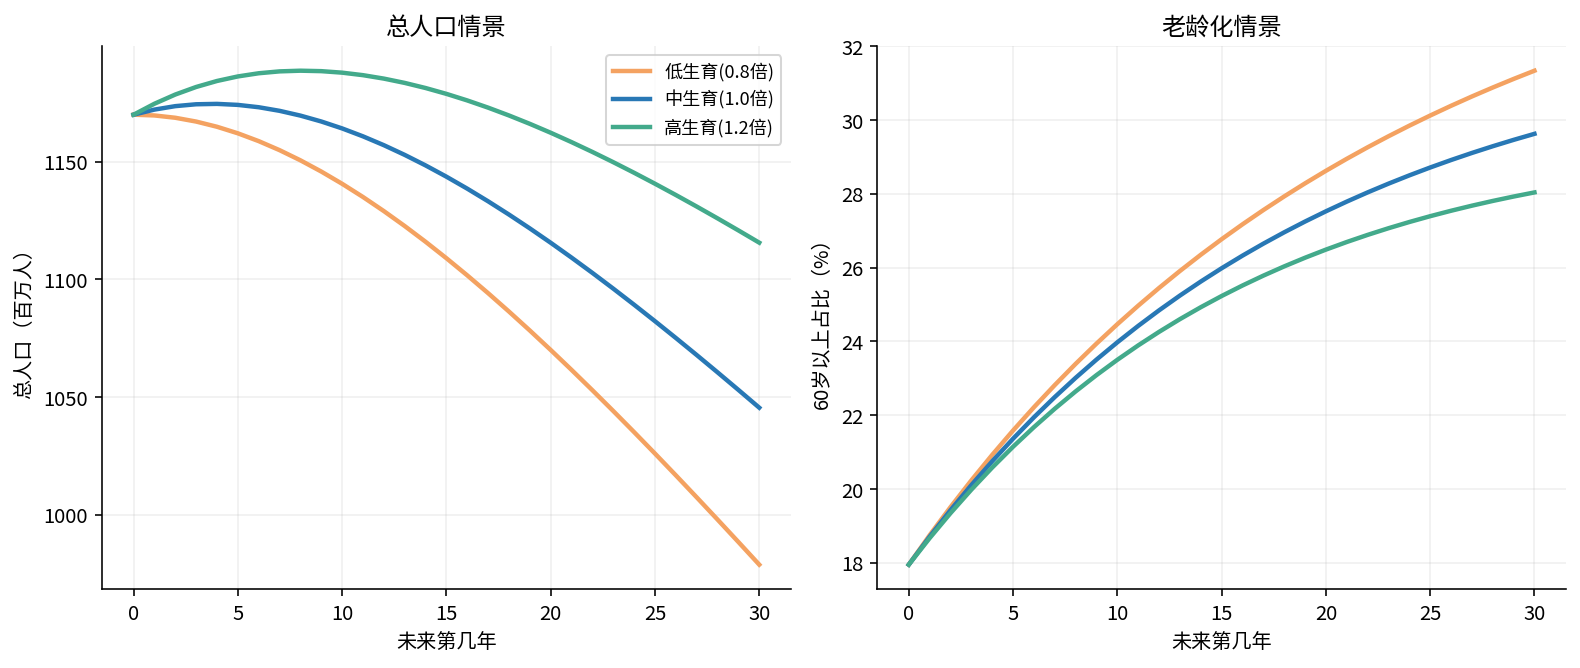

In [4]:
# 案例2A：Leslie 型年龄结构差分方程，三种生育情景
groups = ['0–17', '18–34', '35–59', '60–79', '80+']
n0 = np.array([230., 300., 430., 180., 30.])  # 百万人，教学示例
A_base = np.array([
    [0.943, 0.030, 0.008, 0.000, 0.000],
    [0.055, 0.939, 0.000, 0.000, 0.000],
    [0.000, 0.059, 0.957, 0.000, 0.000],
    [0.000, 0.000, 0.040, 0.931, 0.000],
    [0.000, 0.000, 0.000, 0.040, 0.910],
])

def project_population(fertility_multiplier, years=30):
    A = A_base.copy()
    A[0, 1:3] *= fertility_multiplier
    hist = [n0.copy()]
    for _ in range(years):
        hist.append(A @ hist[-1])
    return np.asarray(hist)

scenarios = {'低生育(0.8倍)': 0.8, '中生育(1.0倍)': 1.0, '高生育(1.2倍)': 1.2}
pop_hist = {name: project_population(mult) for name, mult in scenarios.items()}
rows = []
for name, hist in pop_hist.items():
    for year in [0, 10, 20, 30]:
        total = hist[year].sum()
        rows.append({
            '情景': name, '预测年': year, '总人口(百万人)': total,
            '0–17岁(百万人)': hist[year, 0],
            '60岁以上占比(%)': 100*hist[year, 3:].sum()/total
        })
result_table = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
palette = [COLORS['orange'], COLORS['blue'], COLORS['green']]
for (name, hist), color in zip(pop_hist.items(), palette):
    total = hist.sum(axis=1)
    old_share = 100*hist[:, 3:].sum(axis=1)/total
    axes[0].plot(range(31), total, label=name, color=color, linewidth=2.2)
    axes[1].plot(range(31), old_share, label=name, color=color, linewidth=2.2)
axes[0].set(xlabel='未来第几年', ylabel='总人口（百万人）', title='总人口情景')
axes[1].set(xlabel='未来第几年', ylabel='60岁以上占比（%）', title='老龄化情景')
axes[0].legend(fontsize=9)
fig.tight_layout()
show_result(result_table.round(2), fig)

## 2.5 图表应该怎么解释？

### 第一层：总量

高生育情景通常让总人口更高，但这种影响不会在第一年突然放大。新出生的人先进入儿童组，经过多年才进入生育和劳动年龄组，所以人口系统存在明显的**代际滞后**。

### 第二层：结构

60 岁以上占比受两股力量共同影响：

1. 现有中年人口不断进入老年组；
2. 新生人口改变总人口的分母和未来年龄结构。

因此，提高生育率不会让当前老年人口变少，只可能在较长时间尺度上缓解老龄人口占比。政策讨论必须区分“老年人数”和“老龄化比例”。

### 第三层：为什么不能把情景曲线当成准确预言？

矩阵 $A$ 被假设 30 年不变，但现实中生育意愿、医疗水平、迁移和政策都会变化。情景模型的价值是展示“如果这些条件成立，系统会怎样”，而不是宣称某年一定等于某个数。

年龄组,低生育(0.8倍),中生育(1.0倍),高生育(1.2倍)
0–17,151.362910,184.800001,220.582920
18–34,181.407824,201.014871,221.408376
35–59,339.247481,349.911457,360.824245
60–79,214.259823,216.821990,219.423529
80+,92.419697,92.883428,93.352144


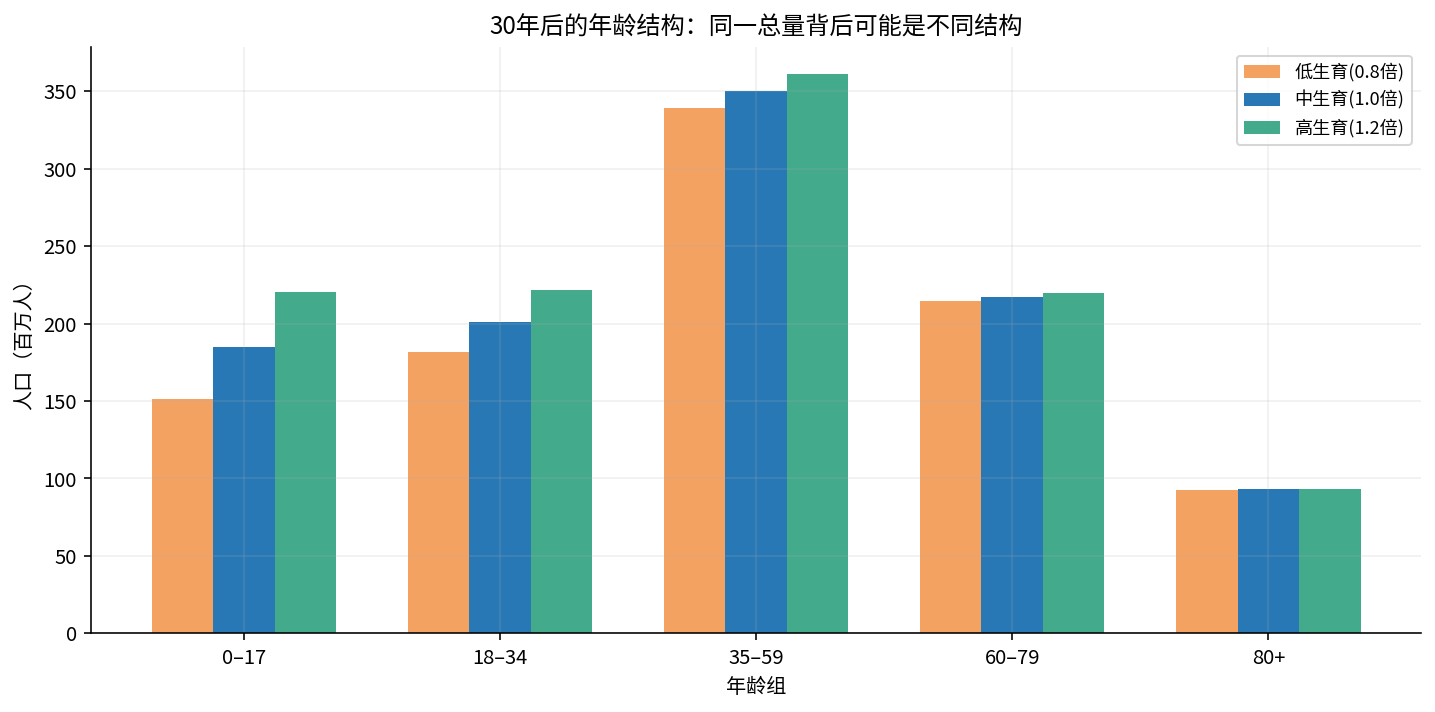

In [5]:
# 案例2B：看30年后的年龄结构，而不只看总人口
final_structure = pd.DataFrame({
    name: hist[-1] for name, hist in pop_hist.items()
}, index=groups)
result_table = final_structure.reset_index().rename(columns={'index': '年龄组'})

fig, ax = plt.subplots(figsize=(10, 5.0))
x = np.arange(len(groups))
width = 0.24
for i, (name, color) in enumerate(zip(scenarios, palette)):
    ax.bar(x + (i-1)*width, final_structure[name], width=width, label=name, color=color)
ax.set_xticks(x, groups)
ax.set(xlabel='年龄组', ylabel='人口（百万人）', title='30年后的年龄结构：同一总量背后可能是不同结构')
ax.legend(fontsize=9)
fig.tight_layout()
show_result(result_table.round(2), fig)

## 2.6 模型合理性检查与改进

### 本课已经能检查什么？

- 所有人口都应非负；
- 每年的输出只由上一年和矩阵决定；
- 调高生育项不应让同期儿童长期更少；
- 年龄结构变化应有滞后，不应所有组同时跳变。

### 正式国赛论文还应补什么？

1. 用真实人口普查和抽样调查数据初始化；
2. 把男女分开，因为出生数取决于育龄女性人口；
3. 使用单岁或 5 岁年龄组，而不是本课的宽年龄段；
4. 加入城镇/乡村、地区和流动人口；
5. 让生育率、死亡率随年份变化；
6. 回代历史年份验证：用早期数据预测已知的后期，再计算误差；
7. 对政策情景做区间预测，而不是只报点预测。

### 小白最容易犯的错

- 把矩阵中的每个数都叫“概率”，却出现同一列无解释地远大于 1；
- 使用总人口指数增长，却在结论中大谈年龄结构；
- 参数没有单位、初始年份不清楚；
- 画了 100 年曲线，却不讨论固定参数长期外推是否可信。

# 案例三｜2016 美赛 A 题：A Hot Bath

## 3.1 赛题是什么？

一个人在普通浴缸里洗澡。水会逐渐冷却，人可以持续加入少量热水，多余的水从溢流口流走。题目要求建立水温随空间和时间变化的模型，寻找既能保持温度接近初始值、又不过度浪费水的策略，还要讨论浴缸、人体、动作和泡泡浴的影响。

这题看似生活化，实际包含四个冲突目标：

- 水温要接近舒适目标；
- 各处水温要均匀；
- 用水要少；
- 策略要可操作。

## 3.2 从最简单的热量守恒开始

若先把整缸水看成完全混匀，温度 $T(t)$ 满足：

$$
\frac{dT}{dt}=\frac{q}{V}(T_{in}-T)-k(T-T_a).
$$

- $q$：热水流量，升/分钟；
- $V$：浴缸水体积，升；
- $T_{in}$：进水温度；
- $T_a$：环境等效温度；
- $k$：向空气、浴缸壁和人体散热的综合系数，1/分钟。

第一项是“热水带来的净升温”，第二项是“与环境温差造成的降温”。当 $T=T_a$ 时，环境散热项为 0，这比写成 $-kT$ 更合理。

## 3.3 为什么还要双区域模型？

官方题目明确要求考虑空间。完整做法可能是偏微分方程，但小白可以先把浴缸分成两个区域：

- $T_1$：靠近水龙头；
- $T_2$：远离水龙头。

$$
\begin{aligned}
\frac{dT_1}{dt}&=\frac{2q}{V}(T_{in}-T_1)-k(T_1-T_a)-m(T_1-T_2),\\
\frac{dT_2}{dt}&=-k(T_2-T_a)+m(T_1-T_2).
\end{aligned}
$$

$m$ 是混合强度：

- 人不动时 $m$ 小，热水容易集中在龙头附近；
- 轻微搅动时 $m$ 大，两处温度更快接近。

这个模型虽然只有两个“空间格子”，但已经能回答一个重要问题：**加更多热水不一定等于更均匀；适当混合可能更节水。**

### 教学参数

- $V=180$ L，$T_{in}=55^\circ C$，$T_a=22^\circ C$；
- 初始两区均为 $40^\circ C$；
- $k=0.018$/min；
- 比较流量 $q\in\{0,1,2,3,4\}$ L/min；
- 比较静止 $m=0.03$/min 和轻微搅动 $m=0.18$/min。

这些是教学假设，不是某一真实浴缸的标定值。

## 3.4 把“最好策略”写成可计算指标

假设舒适目标为 $40^\circ C$。定义：

$$
J=\underbrace{\text{平均温度偏差}}_{越小越舒适}
+0.35\underbrace{\text{平均空间温差}}_{越小越均匀}
+0.020\underbrace{\text{总用水量}}_{越小越节水}.
$$

注意：三个权重不是自然常数，而是决策者偏好。若用户极度重视节水，应提高用水权重；若更看重舒适，应提高温度偏差权重。

竞赛中写“最优”之前，一定要说明“按什么目标最优”。

动作,流量(L/min),60分钟用水(L),末温均值(℃),平均偏温(℃),平均空间温差(℃),综合代价J
轻微搅动,3.0,180.0,37.839802,1.414634,1.325269,5.478478
轻微搅动,4.0,240.0,39.792491,0.127175,1.609476,5.490491
轻微搅动,2.0,120.0,35.374758,2.942973,0.976912,5.684892
轻微搅动,1.0,60.0,32.217429,4.774638,0.544372,6.165168
静止,1.0,60.0,32.061653,4.843056,2.059214,6.763781
静止,2.0,120.0,34.888813,3.169596,3.622245,6.837381
轻微搅动,0.0,0.0,28.112719,6.993256,0.000000,6.993256
静止,0.0,0.0,28.112719,6.993256,0.000000,6.993256
静止,3.0,180.0,36.973186,1.841692,4.835065,7.133965
静止,4.0,240.0,38.552612,0.769521,5.795447,7.597927


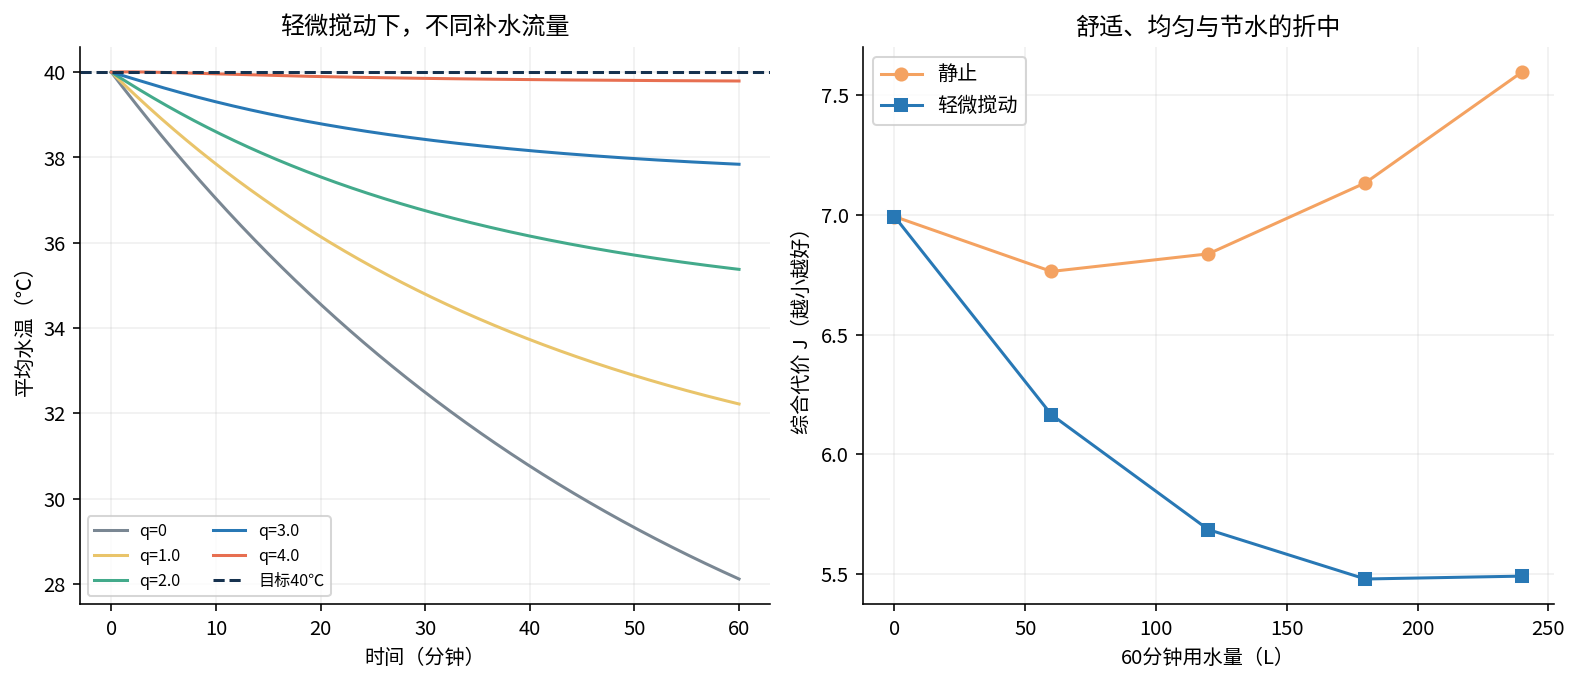

In [6]:
# 案例3A：双区域浴缸模型，比较流量与搅动策略
V, Tin, Ta, T0, k_loss = 180.0, 55.0, 22.0, 40.0, 0.018
bath_t = np.linspace(0, 60, 601)

def solve_bath(q, mixing):
    def rhs(t, y):
        T1, T2 = y
        dT1 = 2*q/V*(Tin-T1) - k_loss*(T1-Ta) - mixing*(T1-T2)
        dT2 = -k_loss*(T2-Ta) + mixing*(T1-T2)
        return [dT1, dT2]
    return solve_ivp(rhs, (0, 60), [T0, T0], t_eval=bath_t, rtol=1e-9, atol=1e-10)

rows, bath_solutions = [], {}
for motion, mixing in [('静止', 0.03), ('轻微搅动', 0.18)]:
    for q in [0, 1.0, 2.0, 3.0, 4.0]:
        sol = solve_bath(q, mixing)
        T1, T2 = sol.y
        Tavg = (T1+T2)/2
        temp_error = np.trapezoid(np.abs(Tavg-40), sol.t)/60
        spatial_gap = np.trapezoid(np.abs(T1-T2), sol.t)/60
        water = q*60
        score = temp_error + 0.35*spatial_gap + 0.020*water
        rows.append({'动作': motion, '流量(L/min)': q, '60分钟用水(L)': water,
                     '末温均值(℃)': Tavg[-1], '平均偏温(℃)': temp_error,
                     '平均空间温差(℃)': spatial_gap, '综合代价J': score})
        bath_solutions[(motion, q)] = sol
result_table = pd.DataFrame(rows).sort_values('综合代价J')
best_motion = result_table.iloc[0]['动作']
best_q = float(result_table.iloc[0]['流量(L/min)'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for q, color in zip([0, 1.0, 2.0, 3.0, 4.0], [COLORS['gray'], COLORS['yellow'], COLORS['green'], COLORS['blue'], COLORS['red']]):
    sol = bath_solutions[('轻微搅动', q)]
    axes[0].plot(sol.t, sol.y.mean(axis=0), label=f'q={q}', color=color)
for motion, marker, color in [('静止', 'o', COLORS['orange']), ('轻微搅动', 's', COLORS['blue'])]:
    part = result_table[result_table['动作']==motion].sort_values('流量(L/min)')
    axes[1].plot(part['60分钟用水(L)'], part['综合代价J'], marker=marker, label=motion, color=color)
axes[0].axhline(40, color=COLORS['navy'], linestyle='--', label='目标40℃')
axes[0].set(xlabel='时间（分钟）', ylabel='平均水温（℃）', title='轻微搅动下，不同补水流量')
axes[1].set(xlabel='60分钟用水量（L）', ylabel='综合代价 J（越小越好）', title='舒适、均匀与节水的折中')
axes[0].legend(ncol=2, fontsize=8)
axes[1].legend()
fig.tight_layout()
show_result(result_table.round(3), fig)

## 3.5 结果怎么读？

1. **不加热水**最节水，但温度偏差通常最大；如果只优化用水量，会得到“不要洗澡”的荒谬策略，所以目标函数必须包含舒适度。
2. **流量太大**可能保持较高温度，却浪费大量水；综合代价不一定最低。
3. **轻微搅动**减少两个区域的温差。它不直接产生热量，但让龙头附近的热量更快分散，因此提高“每升热水”的有效性。
4. 表格第一行只是当前权重下的最佳策略。改变权重或参数，最佳流量可能变化。这不是模型失败，而是在说明最优策略取决于偏好和环境。

下面把最佳策略的两个区域分开画，检查空间温差。

指标,数值
最佳动作,轻微搅动
最佳流量(L/min),3.0
60分钟用水(L),180.0
末端近龙头温度(℃),38.563165
末端远端温度(℃),37.116439
最大空间温差(℃),1.446726
最大温差发生分钟,60.0


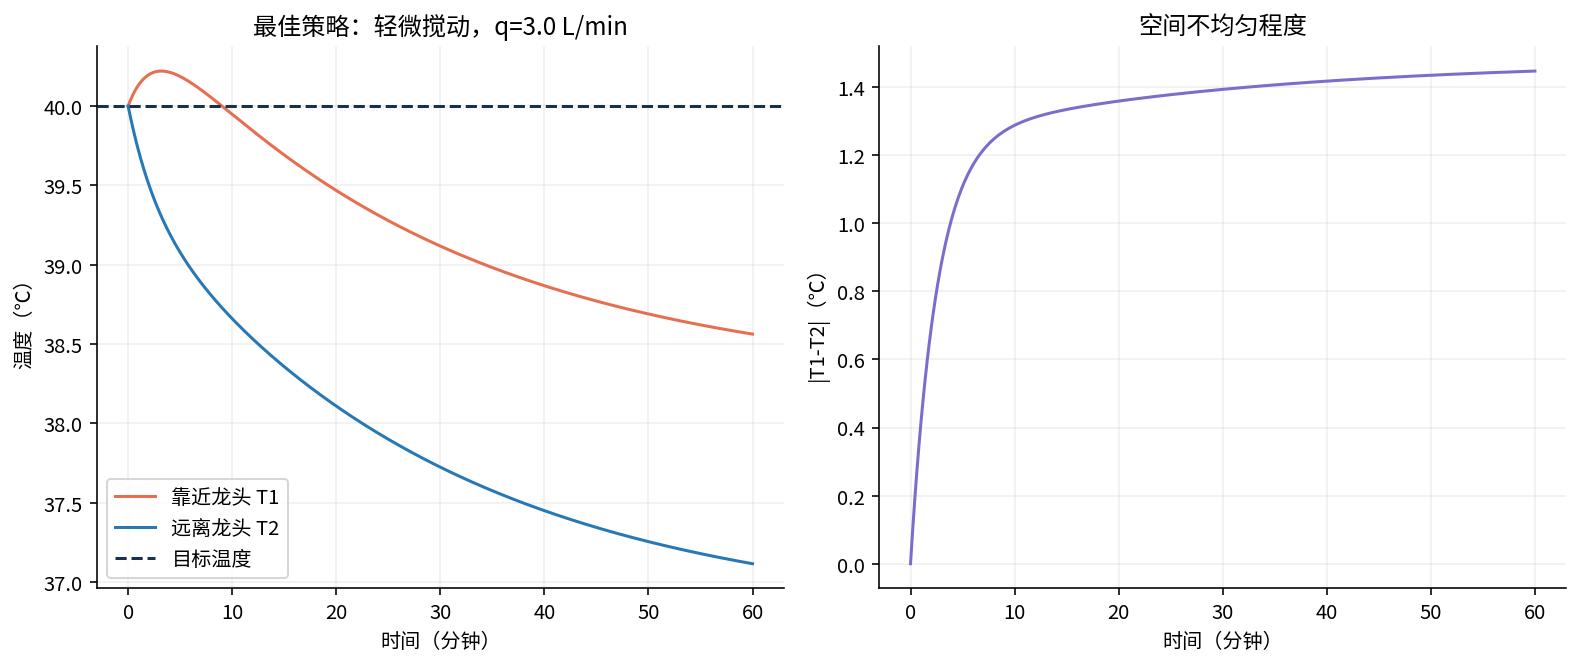

In [7]:
# 案例3B：检查当前综合指标下的最佳策略及空间温差
best_sol = bath_solutions[(best_motion, best_q)]
T1, T2 = best_sol.y
gap = np.abs(T1-T2)
result_table = pd.DataFrame({
    '指标': ['最佳动作', '最佳流量(L/min)', '60分钟用水(L)', '末端近龙头温度(℃)',
            '末端远端温度(℃)', '最大空间温差(℃)', '最大温差发生分钟'],
    '数值': [best_motion, best_q, 60*best_q, T1[-1], T2[-1], gap.max(), best_sol.t[np.argmax(gap)]]
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
axes[0].plot(best_sol.t, T1, label='靠近龙头 T1', color=COLORS['red'])
axes[0].plot(best_sol.t, T2, label='远离龙头 T2', color=COLORS['blue'])
axes[0].axhline(40, linestyle='--', color=COLORS['navy'], label='目标温度')
axes[0].set(xlabel='时间（分钟）', ylabel='温度（℃）', title=f'最佳策略：{best_motion}，q={best_q} L/min')
axes[1].plot(best_sol.t, gap, color=COLORS['purple'])
axes[1].set(xlabel='时间（分钟）', ylabel='|T1-T2|（℃）', title='空间不均匀程度')
axes[0].legend()
fig.tight_layout()
show_result(result_table, fig)

## 3.6 怎样讨论题目要求中的其他因素？

### 浴缸形状和体积

- $V$ 越大，同样流量 $q$ 的作用越弱，因为 $q/V$ 变小；
- 表面积/体积比越大，通常散热越快，应让 $k$ 随几何变化；
- 复杂形状可能产生回流死区，需要更多空间区域或流体仿真。

### 人体

人体排开一部分水，使有效 $V$ 变小；人体温度和热容还会形成额外换热项。可加入人体温度 $T_b$：

$$C_b\frac{dT_b}{dt}=h_b(T_{water}-T_b).$$

### 人的动作

在本模型里主要体现在混合系数 $m$。动作越大，温度越均匀，但人体与水、空气的换热也可能加强，因此不应无限增大 $m$ 而忽略其他效应。

### 泡泡浴

泡沫层可能减少水面蒸发和对流散热，可把 $k$ 调小。但泡沫也会改变混合与温度测量，正式论文应查实验数据或做实验标定。

## 3.7 正式美赛论文还应补什么？

- 用实验或文献估计 $k,m$；
- 做参数敏感性和不确定性分析；
- 使用更多空间格点、热传导 PDE 或 CFD；
- 允许流量随时间变化，求最优控制 $q(t)$；
- 用 Pareto 前沿呈现舒适与节水的多目标折中；
- 把策略写成普通用户能执行的一页非技术说明。

# 案例四｜2021 美赛 A 题：Fungi

## 4.1 赛题是什么？

题目围绕真菌分解木质纤维展开。研究背景指出，不同真菌的生长速度和对温度、湿度变化的耐受能力存在权衡：有些长得快但对环境变化敏感，有些长得慢却更耐受。题目要求研究不同真菌组合、环境条件与分解速率之间的关系。

核心机制可以概括为：

> 环境影响真菌生长 → 真菌之间竞争 → 真菌数量影响木材分解 → 木材剩余量继续随时间下降。

这正是多状态耦合微分方程。

## 4.2 本课的三类状态

- $F_s(t)$：慢生、耐受型真菌生物量；
- $F_f(t)$：快生、敏感型真菌生物量；
- $W(t)$：剩余木材比例，初始为 1。

两个真菌种群使用带竞争的 Logistic 模型：

$$
\frac{dF_s}{dt}=r_s(t)F_s\left(1-\frac{F_s+\alpha_{sf}F_f}{K}\right),
$$

$$
\frac{dF_f}{dt}=r_f(t)F_f\left(1-\frac{F_f+\alpha_{fs}F_s}{K}\right).
$$

木材分解：

$$
\frac{dW}{dt}=-(d_sF_s+d_fF_f)W.
$$

真菌越多、单位生物量分解能力越强，木材下降越快；乘上 $W$ 表示木材越少，剩余可分解底物也越少。

## 4.3 环境怎样进入生长率？

让温度和湿度随时间变化：

$$
T(t)=T_0+A_T\sin(2\pi t/30),\qquad
M(t)=M_0+A_M\sin(2\pi t/24+0.8).
$$

环境适合度使用钟形函数：

$$
g_j(T,M)=\exp\left[-\left(\frac{T-T_j^*}{w_{T,j}}\right)^2-
\left(\frac{M-M_j^*}{w_{M,j}}\right)^2\right],
$$

$$r_j(t)=r_{j,\max}g_j(T(t),M(t)).$$

怎么理解？

- 离最适温湿度越远，$g_j$ 越小；
- 快生型的 $r_{max}$ 大，但耐受宽度 $w$ 小，所以环境一波动就“掉速”；
- 慢生型的最大速度小，但 $w$ 大，因此波动环境中更稳。

这就是“速度—耐受性权衡”的数学翻译。

## 4.4 需要比较哪些情景？

我们设置：

- 稳定环境：温湿度振幅较小；
- 波动环境：振幅较大；
- 慢生型单独、快生型单独、两者混合。

关键输出：

- 180 天后剩余木材比例；
- 达到 50% 木材剩余量所需时间；
- 两种真菌最终生物量；
- 混合是否一定优于单一物种。

最后一个问题特别重要：多样性可能提高环境波动下的稳健性，但竞争也可能降低某一高效物种的数量，所以“物种越多分解越快”不是数学上自动成立的结论。

环境,群落,180天剩余木材(%),降至50%所需天数,最终慢生型生物量,最终快生型生物量
稳定环境,慢生型单独,24.507065,108.75,0.999889,0.000000
稳定环境,快生型单独,7.911190,71.25,0.000000,0.999993
稳定环境,混合群落,10.004174,78.00,0.633423,0.540306
波动环境,慢生型单独,32.197564,134.75,0.988243,0.000000
波动环境,快生型单独,30.816949,139.50,0.000000,0.779459
波动环境,混合群落,27.559417,129.75,0.816787,0.254315


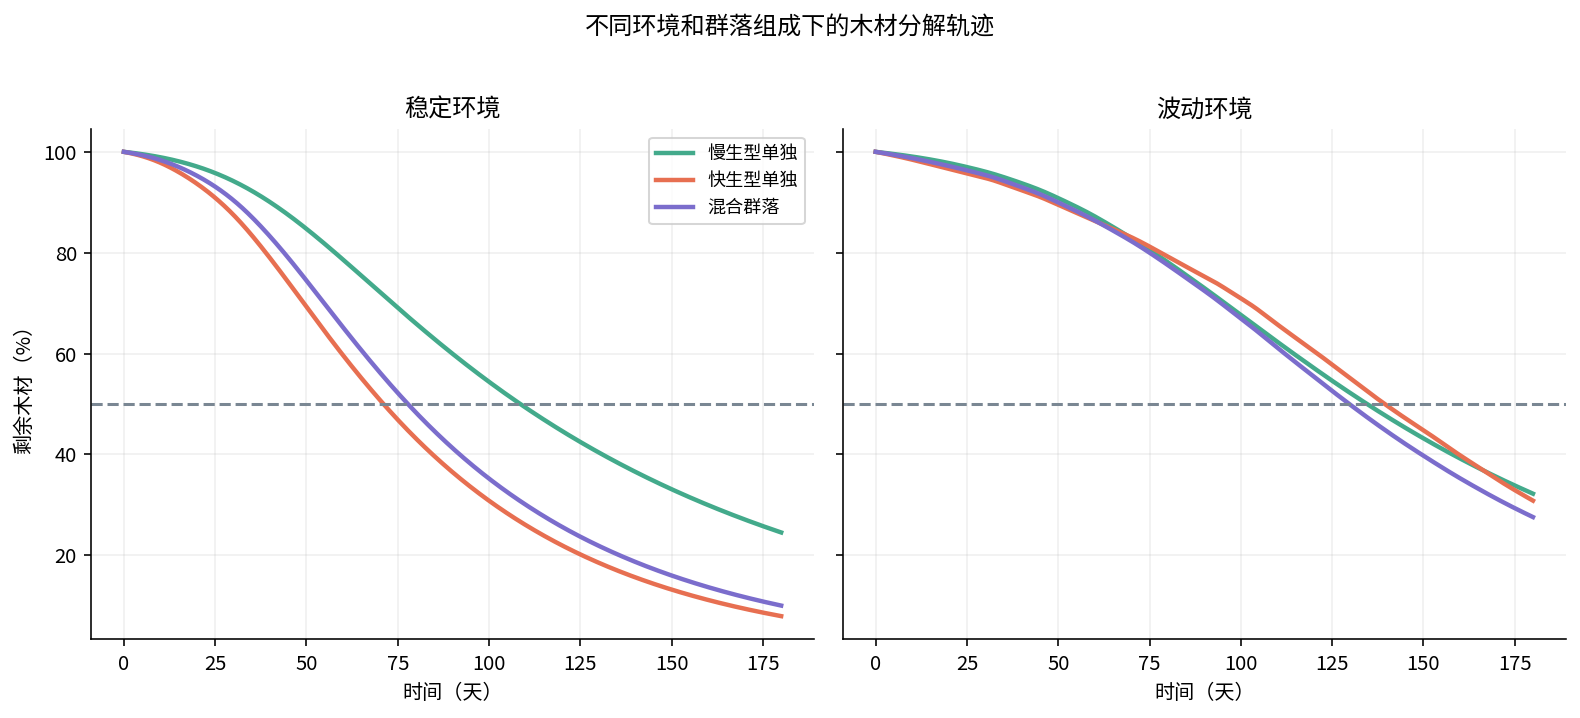

In [8]:
# 案例4A：真菌竞争—木材分解耦合模型
fungi_t = np.linspace(0, 180, 721)
K = 1.0
alpha_sf, alpha_fs = 0.65, 0.75
rmax_s, rmax_f = 0.065, 0.115
decomp_s, decomp_f = 0.010, 0.017

def environment(t, variable):
    if variable:
        return 20 + 7*np.sin(2*np.pi*t/30), 0.62 + 0.25*np.sin(2*np.pi*t/24 + 0.8)
    return 20 + 1*np.sin(2*np.pi*t/30), 0.62 + 0.04*np.sin(2*np.pi*t/24 + 0.8)

def solve_fungi(variable, initial):
    def rhs(t, y):
        Fs, Ff, W = y
        T, M = environment(t, variable)
        # 慢生型耐受宽；快生型耐受窄
        suit_s = np.exp(-((T-20)/9.0)**2 - ((M-0.62)/0.34)**2)
        suit_f = np.exp(-((T-22)/4.5)**2 - ((M-0.68)/0.16)**2)
        rs, rf = rmax_s*suit_s, rmax_f*suit_f
        dFs = rs*Fs*(1-(Fs+alpha_sf*Ff)/K)
        dFf = rf*Ff*(1-(Ff+alpha_fs*Fs)/K)
        dW = -(decomp_s*Fs + decomp_f*Ff)*W
        return [dFs, dFf, dW]
    return solve_ivp(rhs, (0, 180), initial, t_eval=fungi_t, rtol=1e-8, atol=1e-10)

initials = {'慢生型单独': [0.08, 0.0, 1.0], '快生型单独': [0.0, 0.08, 1.0], '混合群落': [0.04, 0.04, 1.0]}
fungi_solutions, rows = {}, []
for env_name, variable in [('稳定环境', False), ('波动环境', True)]:
    for community, initial in initials.items():
        sol = solve_fungi(variable, initial)
        fungi_solutions[(env_name, community)] = sol
        Fs, Ff, W = sol.y
        hit = np.where(W <= 0.5)[0]
        half_day = sol.t[hit[0]] if len(hit) else np.nan
        rows.append({'环境': env_name, '群落': community, '180天剩余木材(%)': 100*W[-1],
                     '降至50%所需天数': half_day, '最终慢生型生物量': Fs[-1], '最终快生型生物量': Ff[-1]})
result_table = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
styles = [('慢生型单独', COLORS['green']), ('快生型单独', COLORS['red']), ('混合群落', COLORS['purple'])]
for ax, env_name in zip(axes, ['稳定环境', '波动环境']):
    for community, color in styles:
        sol = fungi_solutions[(env_name, community)]
        ax.plot(sol.t, 100*sol.y[2], label=community, color=color, linewidth=2.2)
    ax.axhline(50, color=COLORS['gray'], linestyle='--')
    ax.set(xlabel='时间（天）', title=env_name)
axes[0].set_ylabel('剩余木材（%）')
axes[0].legend(fontsize=9)
fig.suptitle('不同环境和群落组成下的木材分解轨迹', y=1.02)
fig.tight_layout()
show_result(result_table.round(3), fig)

## 4.5 怎样读木材分解曲线？

曲线下降越快，表示分解越快。解释时不能只写“红线最低”，而应连接机制：

- 稳定环境接近快生型的适宜区时，快生型凭借较大的最大生长率和分解系数，可能快速占据系统并加快分解；
- 环境波动变大后，快生型的适合度经常下降，慢生耐受型的相对优势上升；
- 混合群落一方面有“保险效应”——不同环境阶段由不同类型发挥作用；另一方面也有竞争，因此结果取决于竞争系数和分解能力。

如果某情景在 180 天内没有降到 50%，表中会显示 `NaN`。这不是程序错误，而是“在观察窗口内未达到阈值”。论文中应写成“>180 天”或“未达到”，不能随意填 180。

指标,数值
温度范围(℃),13.0–27.0
湿度范围,0.37–0.87
慢生型峰值生物量,0.816787
快生型峰值生物量,0.254315
180天剩余木材(%),27.559417
状态最小值(非负性检查),0.04


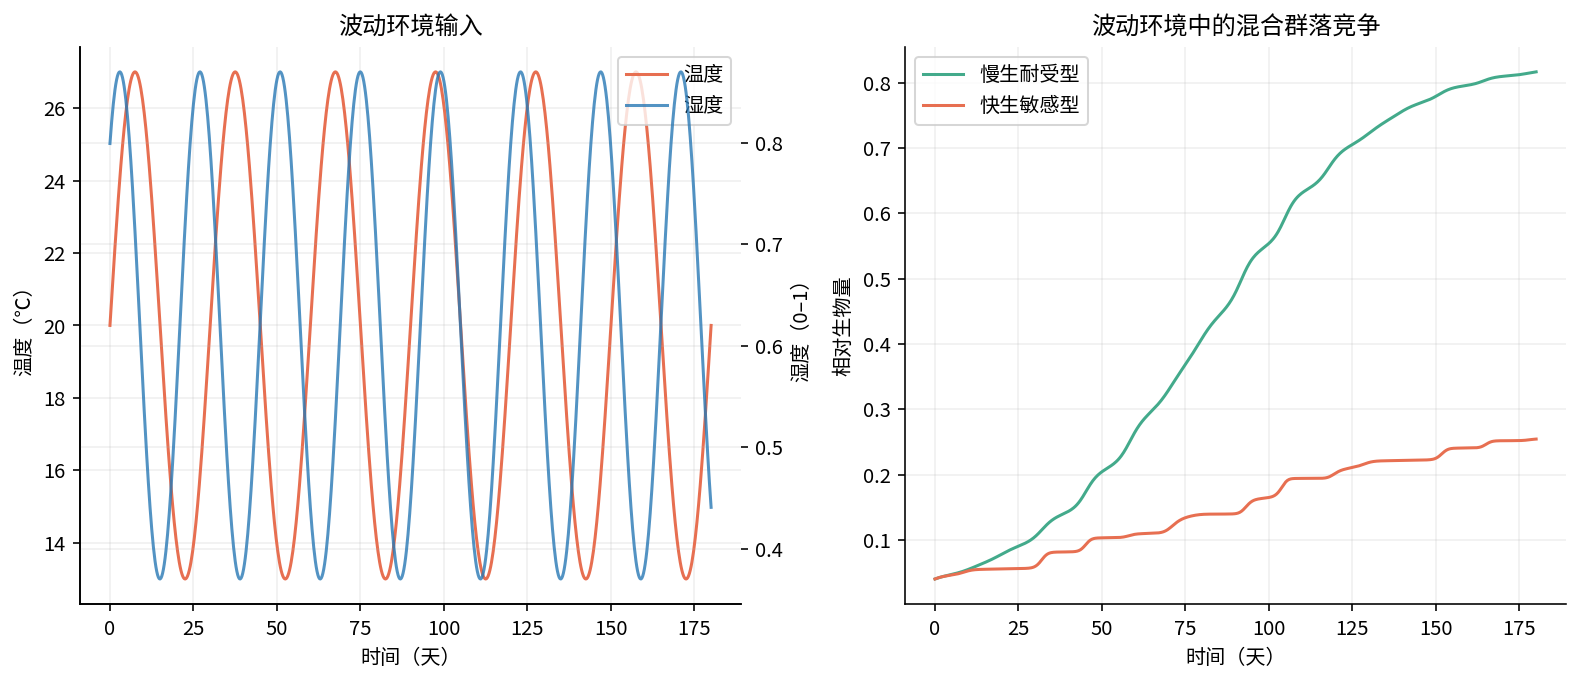

In [9]:
# 案例4B：把环境本身和混合群落的真菌轨迹画出来
T_stable, M_stable = environment(fungi_t, False)
T_var, M_var = environment(fungi_t, True)
sol_mix = fungi_solutions[('波动环境', '混合群落')]
Fs, Ff, W = sol_mix.y

result_table = pd.DataFrame({
    '指标': ['温度范围(℃)', '湿度范围', '慢生型峰值生物量', '快生型峰值生物量',
            '180天剩余木材(%)', '状态最小值(非负性检查)'],
    '数值': [f'{T_var.min():.1f}–{T_var.max():.1f}', f'{M_var.min():.2f}–{M_var.max():.2f}',
           Fs.max(), Ff.max(), 100*W[-1], sol_mix.y.min()]
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax2 = axes[0].twinx()
axes[0].plot(fungi_t, T_var, color=COLORS['red'], label='温度')
ax2.plot(fungi_t, M_var, color=COLORS['blue'], alpha=0.8, label='湿度')
axes[0].set(xlabel='时间（天）', ylabel='温度（℃）', title='波动环境输入')
ax2.set_ylabel('湿度（0–1）')
lines = axes[0].lines + ax2.lines
axes[0].legend(lines, [l.get_label() for l in lines], loc='upper right')
axes[1].plot(sol_mix.t, Fs, label='慢生耐受型', color=COLORS['green'])
axes[1].plot(sol_mix.t, Ff, label='快生敏感型', color=COLORS['red'])
axes[1].set(xlabel='时间（天）', ylabel='相对生物量', title='波动环境中的混合群落竞争')
axes[1].legend()
fig.tight_layout()
show_result(result_table, fig)

## 4.6 模型检查、局限和改进

### 合理性检查

- $F_s,F_f,W$ 不应为负；
- $W$ 只能下降，不能凭空增加；
- 初始没有某真菌且模型没有迁入项时，该真菌应一直为 0；
- 环境完全不适宜时，增长率应接近 0；
- 把分解系数设为 0 后，木材应保持不变。

### 主要局限

1. 温湿度被外生给定，真菌和分解过程不会反过来改变微环境；
2. 竞争系数固定，但真实相互作用可能随环境改变；
3. 没有考虑真菌死亡、迁入、酶活性与木材化学成分；
4. 空间被完全混合，忽略菌丝扩散和木材内部差异；
5. 参数是教学设定，不能直接解释真实生态系统。

### 正式美赛可以怎样升级？

- 用论文数据拟合“生长速度—耐受宽度”关系；
- 增加多物种和功能性状分布；
- 使用 Monte Carlo 环境序列，输出分解时间的概率区间；
- 构造反应—扩散 PDE 表示菌丝空间扩张；
- 用方差分解回答哪个性状或环境因素最关键；
- 用交叉验证或外部实验数据验证分解预测。

# 5. 四道赛题放在一起：什么时候用微分，什么时候用差分？

|案例|时间表达|状态|核心反馈|关键输出|
|---|---|---|---|---|
|SARS|连续的天|S/E/I/R|感染者越多，新暴露越多|峰值、峰值日、累计感染|
|人口|一年一步|五个年龄阶段|年龄迁移与生育有代际滞后|总人口、年龄结构、老龄化|
|浴缸|连续的分钟|两区温度|温差越大，换热越强|舒适、均匀、用水、综合代价|
|真菌|连续的天|两类真菌+木材|竞争、环境适合度、底物减少|剩余木材、半衰时间、稳健性|

## 一句话选择法

- 题目强调“某一瞬间的速度、流率、热量变化” → 优先考虑微分方程；
- 题目按“年、周、代、轮次”更新，或数据天然是周期表 → 优先考虑差分方程；
- 差分方程也可以来自微分方程的数值离散；二者不是敌人，而是不同时间视角。

## 真正通用的能力

四道题表面完全不同，但结构一致：

$$
\boxed{题意\rightarrow状态\rightarrow机制\rightarrow方程\rightarrow参数\rightarrow仿真\rightarrow指标\rightarrow解释\rightarrow验证}
$$

# 6. 从 Notebook 到一篇竞赛论文：建议目录

1. **摘要**：问题、模型、算法、最重要结果，不写空话。
2. **问题重述**：用自己的话说明任务，不整段翻译题面。
3. **问题分析**：解释每一问的难点与总体路线。
4. **模型假设**：每条假设说明为何合理、可能造成什么影响。
5. **符号与单位**：避免参数无单位。
6. **模型建立**：从机制推导方程，解释每一项。
7. **参数估计与数据处理**：来源、清洗、拟合方法、误差。
8. **数值求解**：算法、步长、收敛或精度设置。
9. **结果与分析**：先表后图，回答题目，不只描述线条颜色。
10. **敏感性与稳健性**：参数变化、模型对比、不确定性区间。
11. **模型评价**：优点、局限、适用范围、改进方向。
12. **参考文献与附录**：数据与代码可复现。

## “长而细致”不等于堆字

高质量分析应该不断回答：

- 为什么选这个变量？
- 为什么这一项是加号/减号？
- 参数怎样得到？
- 图中的变化由哪个机制导致？
- 换一组合理参数，结论还成立吗？
- 哪部分是模型结论，哪部分只是建模假设？

# 7. 练习：把课件变成你自己的能力

## 练习 1：SARS 参数敏感性

把隔离后的 $\beta$ 攓成 0.07、0.09、0.11，比较感染峰值和累计感染。说明为什么即使都低于阈值，下降速度仍不同。

## 练习 2：人口历史回测

找一个地区两个相隔 10 年的人口年龄表，用前一个年份初始化，用模型预测后一个年份，计算各年龄组相对误差。不要只拟合总人口。

## 练习 3：浴缸多目标权重

分别设置“节水优先”和“舒适优先”的权重，观察最佳流量是否变化。进一步画出用水量—温度误差散点图，寻找 Pareto 前沿。

## 练习 4：真菌极端环境

逐渐增加温度振幅，画出 180 天剩余木材与振幅的关系。判断慢生耐受型何时开始比快生敏感型更有优势。

## 练习 5：独立选题

从以下方向选一题：药物浓度、湖泊污染、库存补货、谣言传播、捕食者—猎物、电池温度。必须写出状态、单位、初值、方程、参数来源、至少两个情景、一张指标表、一张图和三条局限。

# 8. 最后总结

你不需要先成为微分方程专家，才能开始做动态系统赛题。初学者最稳的顺序是：

1. 用房间、流量、年龄搬家、热量收支等生活语言讲清机制；
2. 再把每个“流入/流出”翻译成一项方程；
3. 用简单基线模型跑通；
4. 提取能回答题目的指标；
5. 做守恒、非负、极端情况和敏感性检查；
6. 最后再增加空间、随机性、时变参数和优化。

四个最短记忆：

$$
\boxed{SEIR：人群在四个状态之间流动}
$$

$$
\boxed{Leslie：明年年龄结构=投影矩阵\times今年年龄结构}
$$

$$
\boxed{浴缸：温度变化=热水输入-环境散热+区域混合}
$$

$$
\boxed{真菌：环境影响生长，竞争影响群落，群落影响分解}
$$

最重要的不是公式有多复杂，而是：**模型中的每一项都能对应现实机制，输出确实回答赛题，结论经得起基本检查。**